# Прогнозирование временного ряда акций «Лукойл»

В работе решается задача прогнозирования цены закрытия акций компании «Лукойл» на основе исторических биржевых данных. Рассматриваются две архитектуры: полносвязная нейронная сеть и сеть со слоями Conv1D. Для каждой архитектуры обучаются две модели — на прогнозирование одного шага вперёд и на прогнозирование сразу десяти шагов прямым способом (когда сеть выдаёт вектор из 10 значений за один проход).

Этапы работы:

1. Загрузка библиотек и подготовка данных.
2. Нормализация и формирование обучающей и тестовой выборок.
3. Обучение полносвязной сети для прогноза на один шаг вперёд.
4. Обучение полносвязной сети для прогноза на 10 шагов вперёд прямым способом.
5. Построение графиков сравнения предсказания и оригинального сигнала по каждому из 10 шагов.
6. Повторение пунктов 3–5 для архитектуры со свёрточным слоем Conv1D.

## Загрузка библиотек

In [1]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# Классы-конструкторы моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, LSTM

# Оптимизаторы
from tensorflow.keras.optimizers import Adam

# Генератор выборки временных рядов
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

## Загрузка данных

Используется база котировок акций «Лукойл» за 2016–2019 годы. Данные загружаются из облачного хранилища двумя файлами и затем объединяются в один массив.

In [3]:
# Загрузка датасетов из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

'18_19.csv'

In [4]:
# Чтение данных в таблицы pandas, столбцы DATE и TIME удаляются за ненадобностью
data16_17 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE', 'TIME'])

# Просмотр размерностей
print(data16_17.shape)
print(data18_19.shape)

(263925, 5)
(217947, 5)


In [5]:
# Объединение двух датасетов в один общий массив
data = pd.concat([data16_17, data18_19]).to_numpy()
print('Форма общего набора данных:', data.shape)

Форма общего набора данных: (481872, 5)


По условию задачи прогнозируется только цена закрытия (Close), поэтому из общего массива выделяется один соответствующий столбец.

In [6]:
# Индексы каналов исходного датасета: Open, Max, Min, Close, Volume
CHANNEL_NAMES = ['Open', 'Max', 'Min', 'Close', 'Volume']
CLOSE_INDEX = CHANNEL_NAMES.index('Close')

# Отбор только канала Close в виде столбца
close_series = data[:, CLOSE_INDEX].reshape(-1, 1)
print('Форма ряда цены закрытия:', close_series.shape)

Форма ряда цены закрытия: (481872, 1)


### Иллюстрация исходного ряда

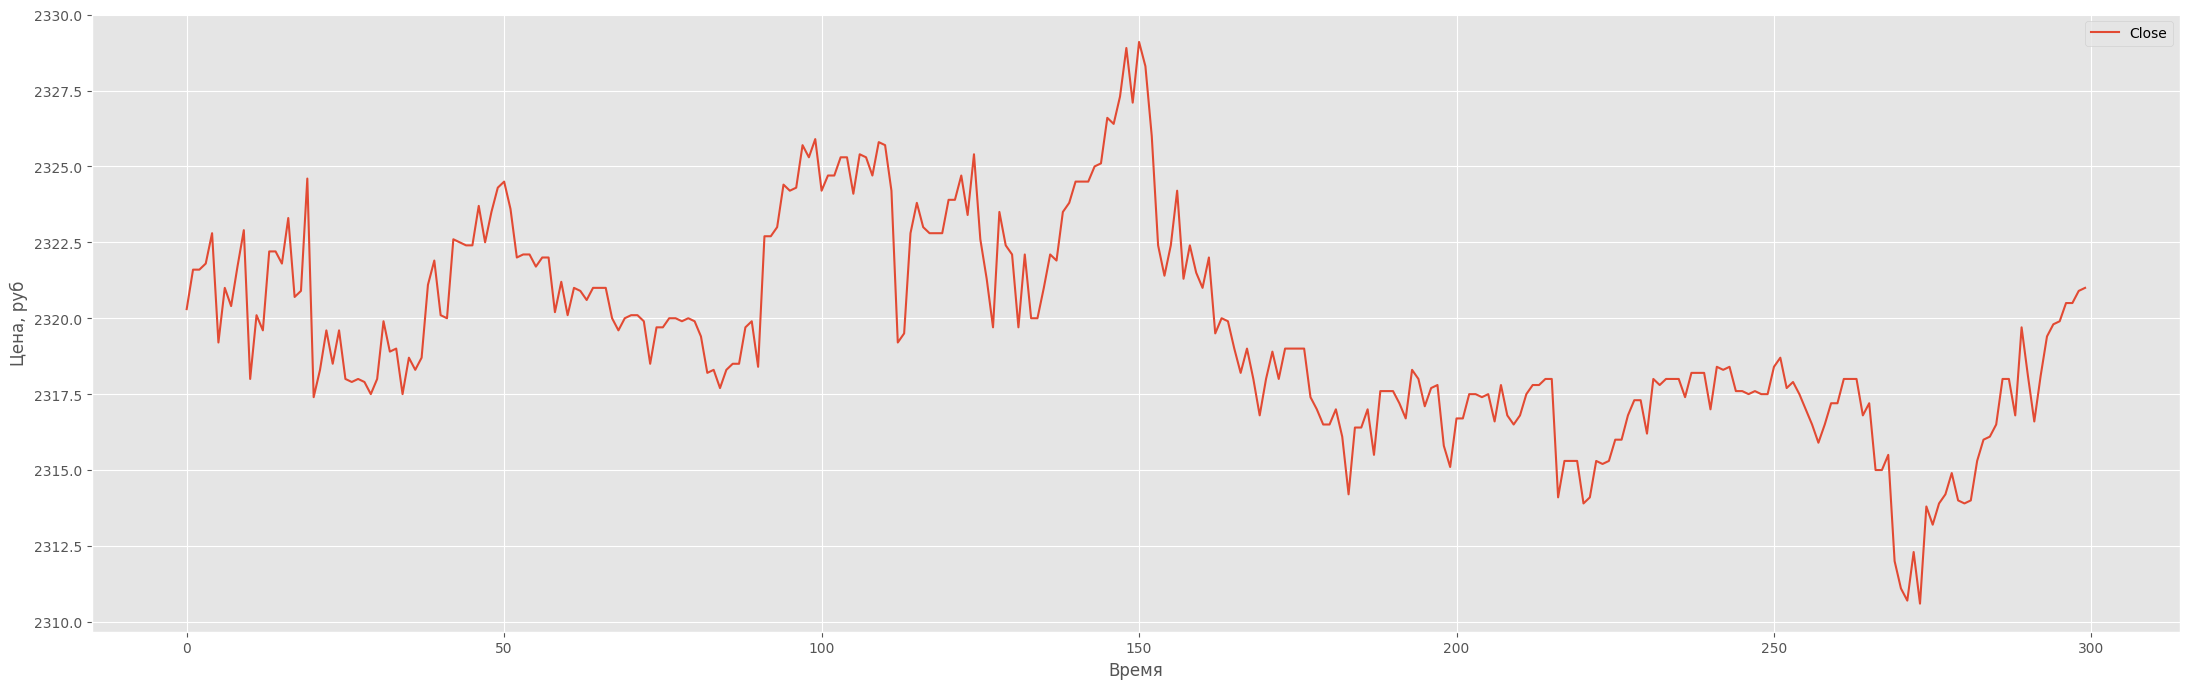

In [7]:
# Отображение фрагмента ряда цены закрытия
start = 100
length = 300

plt.figure(figsize=(22, 7))
plt.plot(close_series[start:start + length], label='Close')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.tight_layout()
plt.show()

## Подготовка выборок

Данные разделяются на обучающую и тестовую части в хронологическом порядке. Для устранения пересечения между выборками между ними оставляется зазор длиной в две длины анализируемой последовательности. Размер обучающей части ограничивается последним отрезком ряда — на минутных данных этого более чем достаточно, чтобы модель уловила локальную динамику цены. После разделения значения масштабируются с помощью MinMaxScaler, обученного только на тренировочных данных.

In [8]:
# Гиперпараметры подготовки данных
SEQ_LEN = 60                              # Длина анализируемой подпоследовательности (1 час истории)
BATCH_SIZE = 256                          # Размер батча генератора
TRAIN_LEN = 100000                        # Размер обучающей части (последние точки)
TEST_LEN = 5000                           # Размер тестовой части

In [9]:
# Разделение по времени с зазором между обучением и тестом.
# Берётся последний отрезок ряда: сначала TRAIN_LEN точек на обучение, затем зазор и TEST_LEN на тест.
total_len = close_series.shape[0]
test_end = total_len
test_start = test_end - TEST_LEN
train_end = test_start - 2 * SEQ_LEN
train_start = train_end - TRAIN_LEN

data_train = close_series[train_start:train_end]
data_test = close_series[test_start:test_end]

# Нормировщик настраивается по обучающим данным
scaler = MinMaxScaler()
scaler.fit(data_train)

# Преобразование обеих частей в float32 — быстрее на GPU и меньше памяти
data_train_sc = scaler.transform(data_train).astype(np.float32)
data_test_sc  = scaler.transform(data_test).astype(np.float32)

print('Train:', data_train_sc.shape)
print('Test :', data_test_sc.shape)

Train: (100000, 1)
Test : (5000, 1)


## Часть 1. Полносвязная сеть, прогноз на один шаг вперёд

Стандартный для задач временных рядов подход: на вход сети подаётся окно из SEQ_LEN последних значений, а сеть должна предсказать одно следующее значение. Для формирования батчей используется TimeseriesGenerator.

In [10]:
# Генератор обучающей выборки
train_gen = TimeseriesGenerator(data_train_sc, data_train_sc,
                                length=SEQ_LEN,
                                stride=1,
                                sampling_rate=1,
                                batch_size=BATCH_SIZE)

# Генератор тестовой выборки выдаёт всю выборку одним батчом
test_gen = TimeseriesGenerator(data_test_sc, data_test_sc,
                               length=SEQ_LEN,
                               stride=1,
                               sampling_rate=1,
                               batch_size=data_test_sc.shape[0])

x_test, y_test = test_gen[0]
print('x_test:', x_test.shape, 'y_test:', y_test.shape)

x_test: (4940, 60, 1) y_test: (4940, 1)


### Архитектура и обучение

In [11]:
# Простая полносвязная сеть с одним скрытым слоем
model_dense_1 = Sequential()
model_dense_1.add(Flatten(input_shape=x_test.shape[1:]))
model_dense_1.add(Dense(150, activation='relu'))
model_dense_1.add(Dense(1, activation='linear'))

model_dense_1.compile(loss='mse', optimizer=Adam(learning_rate=1e-4))
model_dense_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │         9,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,301 (36.33 KB)

 Trainable params: 9,301 (36.33 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Обучение модели
history_d1 = model_dense_1.fit(train_gen,
                               epochs=8,
                               validation_data=test_gen,
                               verbose=1)

Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0819 - val_loss: 2.7109e-04
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1274e-04 - val_loss: 1.4444e-04
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.0453e-04 - val_loss: 1.1798e-04
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.7047e-05 - val_loss: 1.0055e-04
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.5034e-05 - val_loss: 6.2792e-05
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.4799e-05 - val_loss: 6.4357e-05
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.4761e-05 - val_loss: 5.7613e-05
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.2944e-05 - val_loss: 5.5458e-05


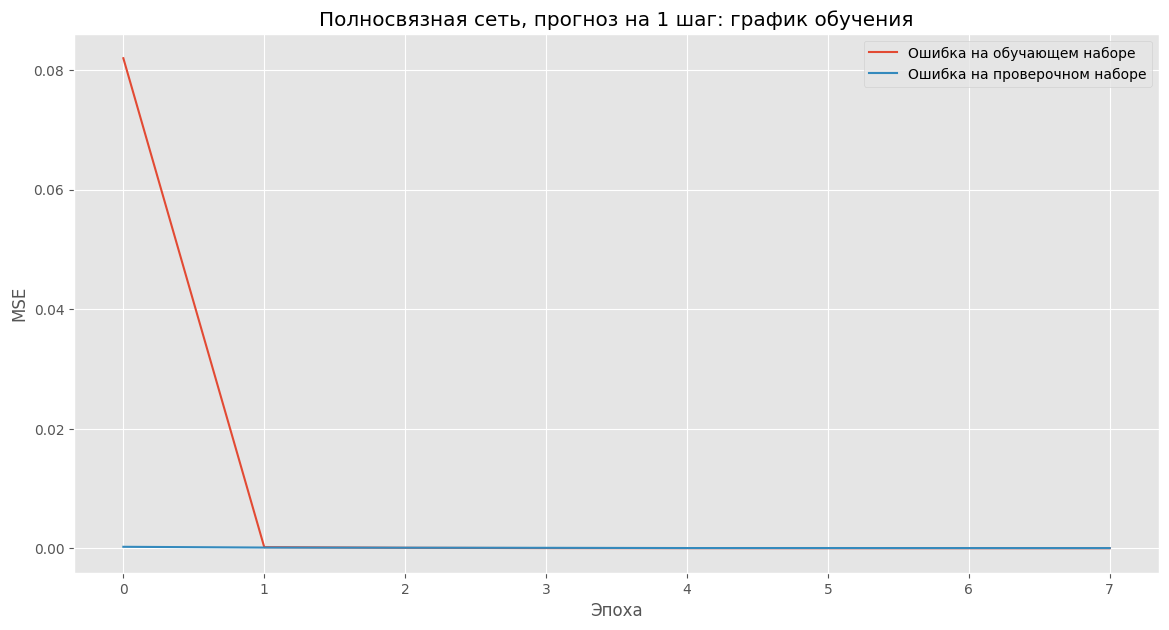

In [13]:
# График ошибки обучения
plt.figure(figsize=(14, 7))
plt.plot(history_d1.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history_d1.history['val_loss'], label='Ошибка на проверочном наборе')
plt.title('Полносвязная сеть, прогноз на 1 шаг: график обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

### Визуализация результата

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


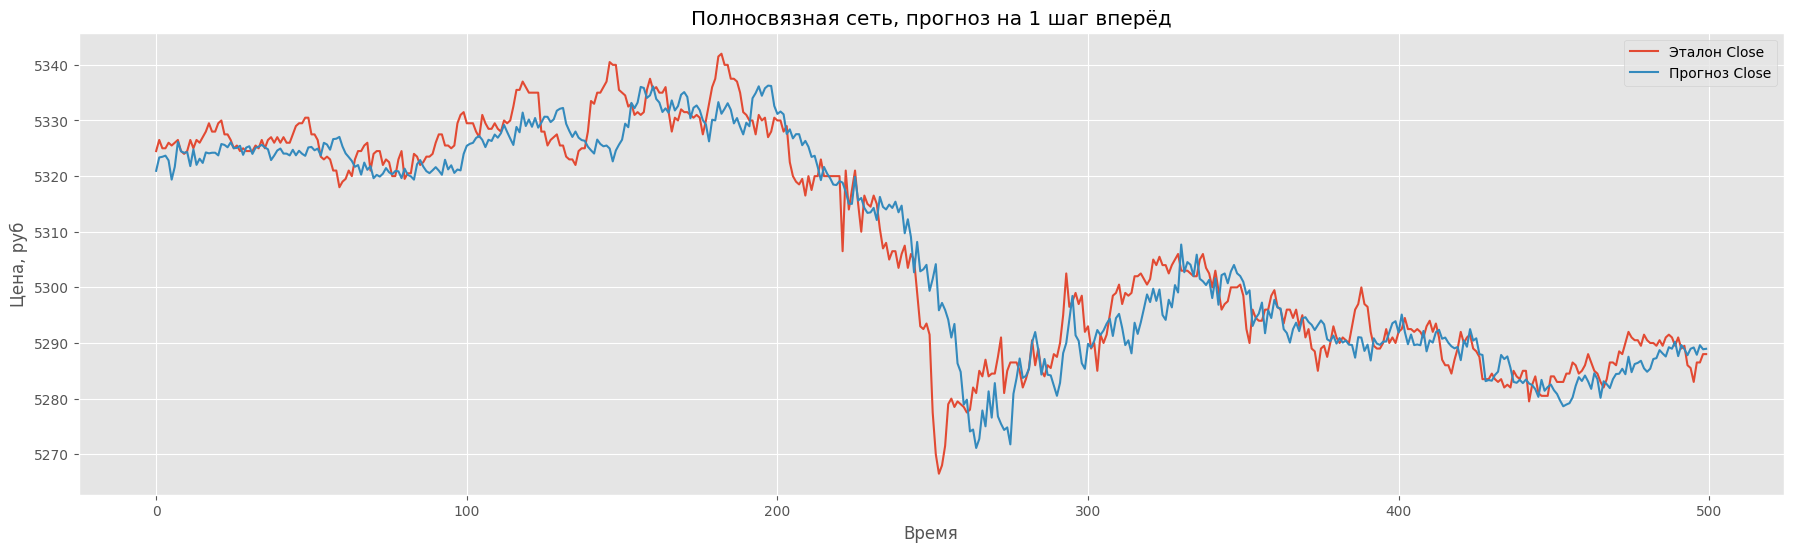

In [14]:
# Предсказание на тестовой выборке и обратная нормализация
y_pred_d1 = scaler.inverse_transform(model_dense_1.predict(x_test))
y_true_d1 = scaler.inverse_transform(y_test)

# Сопоставление прогноза и эталона на участке длиной 500 точек
start = 0
length = 500

plt.figure(figsize=(22, 6))
plt.plot(y_true_d1[start:start + length], label='Эталон Close')
plt.plot(y_pred_d1[start:start + length], label='Прогноз Close')
plt.title('Полносвязная сеть, прогноз на 1 шаг вперёд')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.show()

## Часть 2. Полносвязная сеть, прямой прогноз на 10 шагов вперёд

При прямом способе прогноза на горизонт из нескольких шагов сеть выдаёт сразу вектор из соответствующего числа значений. То есть последний слой имеет 10 нейронов, и каждый нейрон отвечает за свою позицию в горизонте прогноза. Для формирования такой выборки требуется собственный генератор окон, поскольку TimeseriesGenerator одиночное число для метки не масштабируется до 10 значений автоматически.

In [15]:
# Горизонт многошагового прогноза
PREDICT_LAG = 10

# Функция формирования окон признаков и многошаговых меток
def make_multistep(series, seq_len, predict_lag):
    n = series.shape[0] - seq_len - predict_lag + 1
    x = np.stack([series[i:i + seq_len] for i in range(n)]).astype(np.float32)
    y = np.stack([series[i + seq_len:i + seq_len + predict_lag, 0] for i in range(n)]).astype(np.float32)
    return x, y

# Формирование выборок
x_train_m, y_train_m = make_multistep(data_train_sc, SEQ_LEN, PREDICT_LAG)
x_test_m,  y_test_m  = make_multistep(data_test_sc,  SEQ_LEN, PREDICT_LAG)

print('x_train_m:', x_train_m.shape, 'y_train_m:', y_train_m.shape)
print('x_test_m :', x_test_m.shape,  'y_test_m :', y_test_m.shape)

x_train_m: (99931, 60, 1) y_train_m: (99931, 10)
x_test_m : (4931, 60, 1) y_test_m : (4931, 10)


### Архитектура и обучение

In [16]:
# Та же полносвязная архитектура, но с 10 выходами
model_dense_10 = Sequential()
model_dense_10.add(Flatten(input_shape=x_train_m.shape[1:]))
model_dense_10.add(Dense(150, activation='relu'))
model_dense_10.add(Dense(PREDICT_LAG, activation='linear'))

model_dense_10.compile(loss='mse', optimizer=Adam(learning_rate=1e-4))
model_dense_10.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 150)            │         9,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,660 (41.64 KB)

 Trainable params: 10,660 (41.64 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Обучение модели
history_d10 = model_dense_10.fit(x_train_m, y_train_m,
                                 validation_data=(x_test_m, y_test_m),
                                 epochs=8,
                                 batch_size=BATCH_SIZE,
                                 verbose=1)

Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0371 - val_loss: 2.0594e-04
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.4347e-05 - val_loss: 1.6645e-04
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.8137e-05 - val_loss: 1.4352e-04
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9717e-05 - val_loss: 1.2658e-04
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.1601e-05 - val_loss: 1.0354e-04
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.6347e-05 - val_loss: 9.2687e-05
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.4038e-05 - val_loss: 8.8403e-05
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.2383e-05 - val_loss: 8.3225e-05


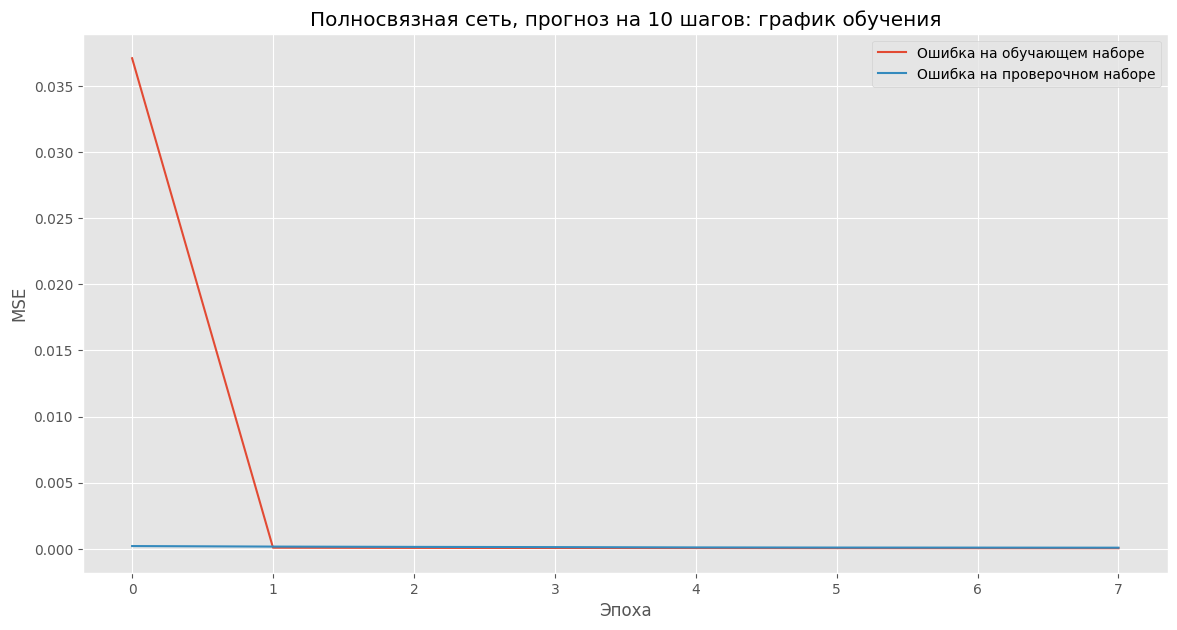

In [18]:
# График ошибки обучения
plt.figure(figsize=(14, 7))
plt.plot(history_d10.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history_d10.history['val_loss'], label='Ошибка на проверочном наборе')
plt.title('Полносвязная сеть, прогноз на 10 шагов: график обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

### Графики сравнения предсказания и оригинального сигнала по 10 шагам

Каждый из 10 графиков соответствует одной позиции в горизонте прогноза: первый график — прогноз на 1 шаг вперёд, второй — на 2 шага вперёд, и так до 10. Эталонный ряд для каждого графика сдвигается во времени на соответствующее число шагов, чтобы сравнение проводилось корректно.

In [19]:
# Получение прогноза и его обратная нормализация
y_pred_m_sc = model_dense_10.predict(x_test_m)

# Канал был один, поэтому inverse_transform применяется к каждому шагу прогноза отдельно
y_pred_m = scaler.inverse_transform(y_pred_m_sc.reshape(-1, 1)).reshape(y_pred_m_sc.shape)
y_true_m = scaler.inverse_transform(y_test_m.reshape(-1, 1)).reshape(y_test_m.shape)

print('Денормализованный прогноз:', y_pred_m.shape)
print('Денормализованный эталон :', y_true_m.shape)

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Денормализованный прогноз: (4931, 10)
Денормализованный эталон : (4931, 10)


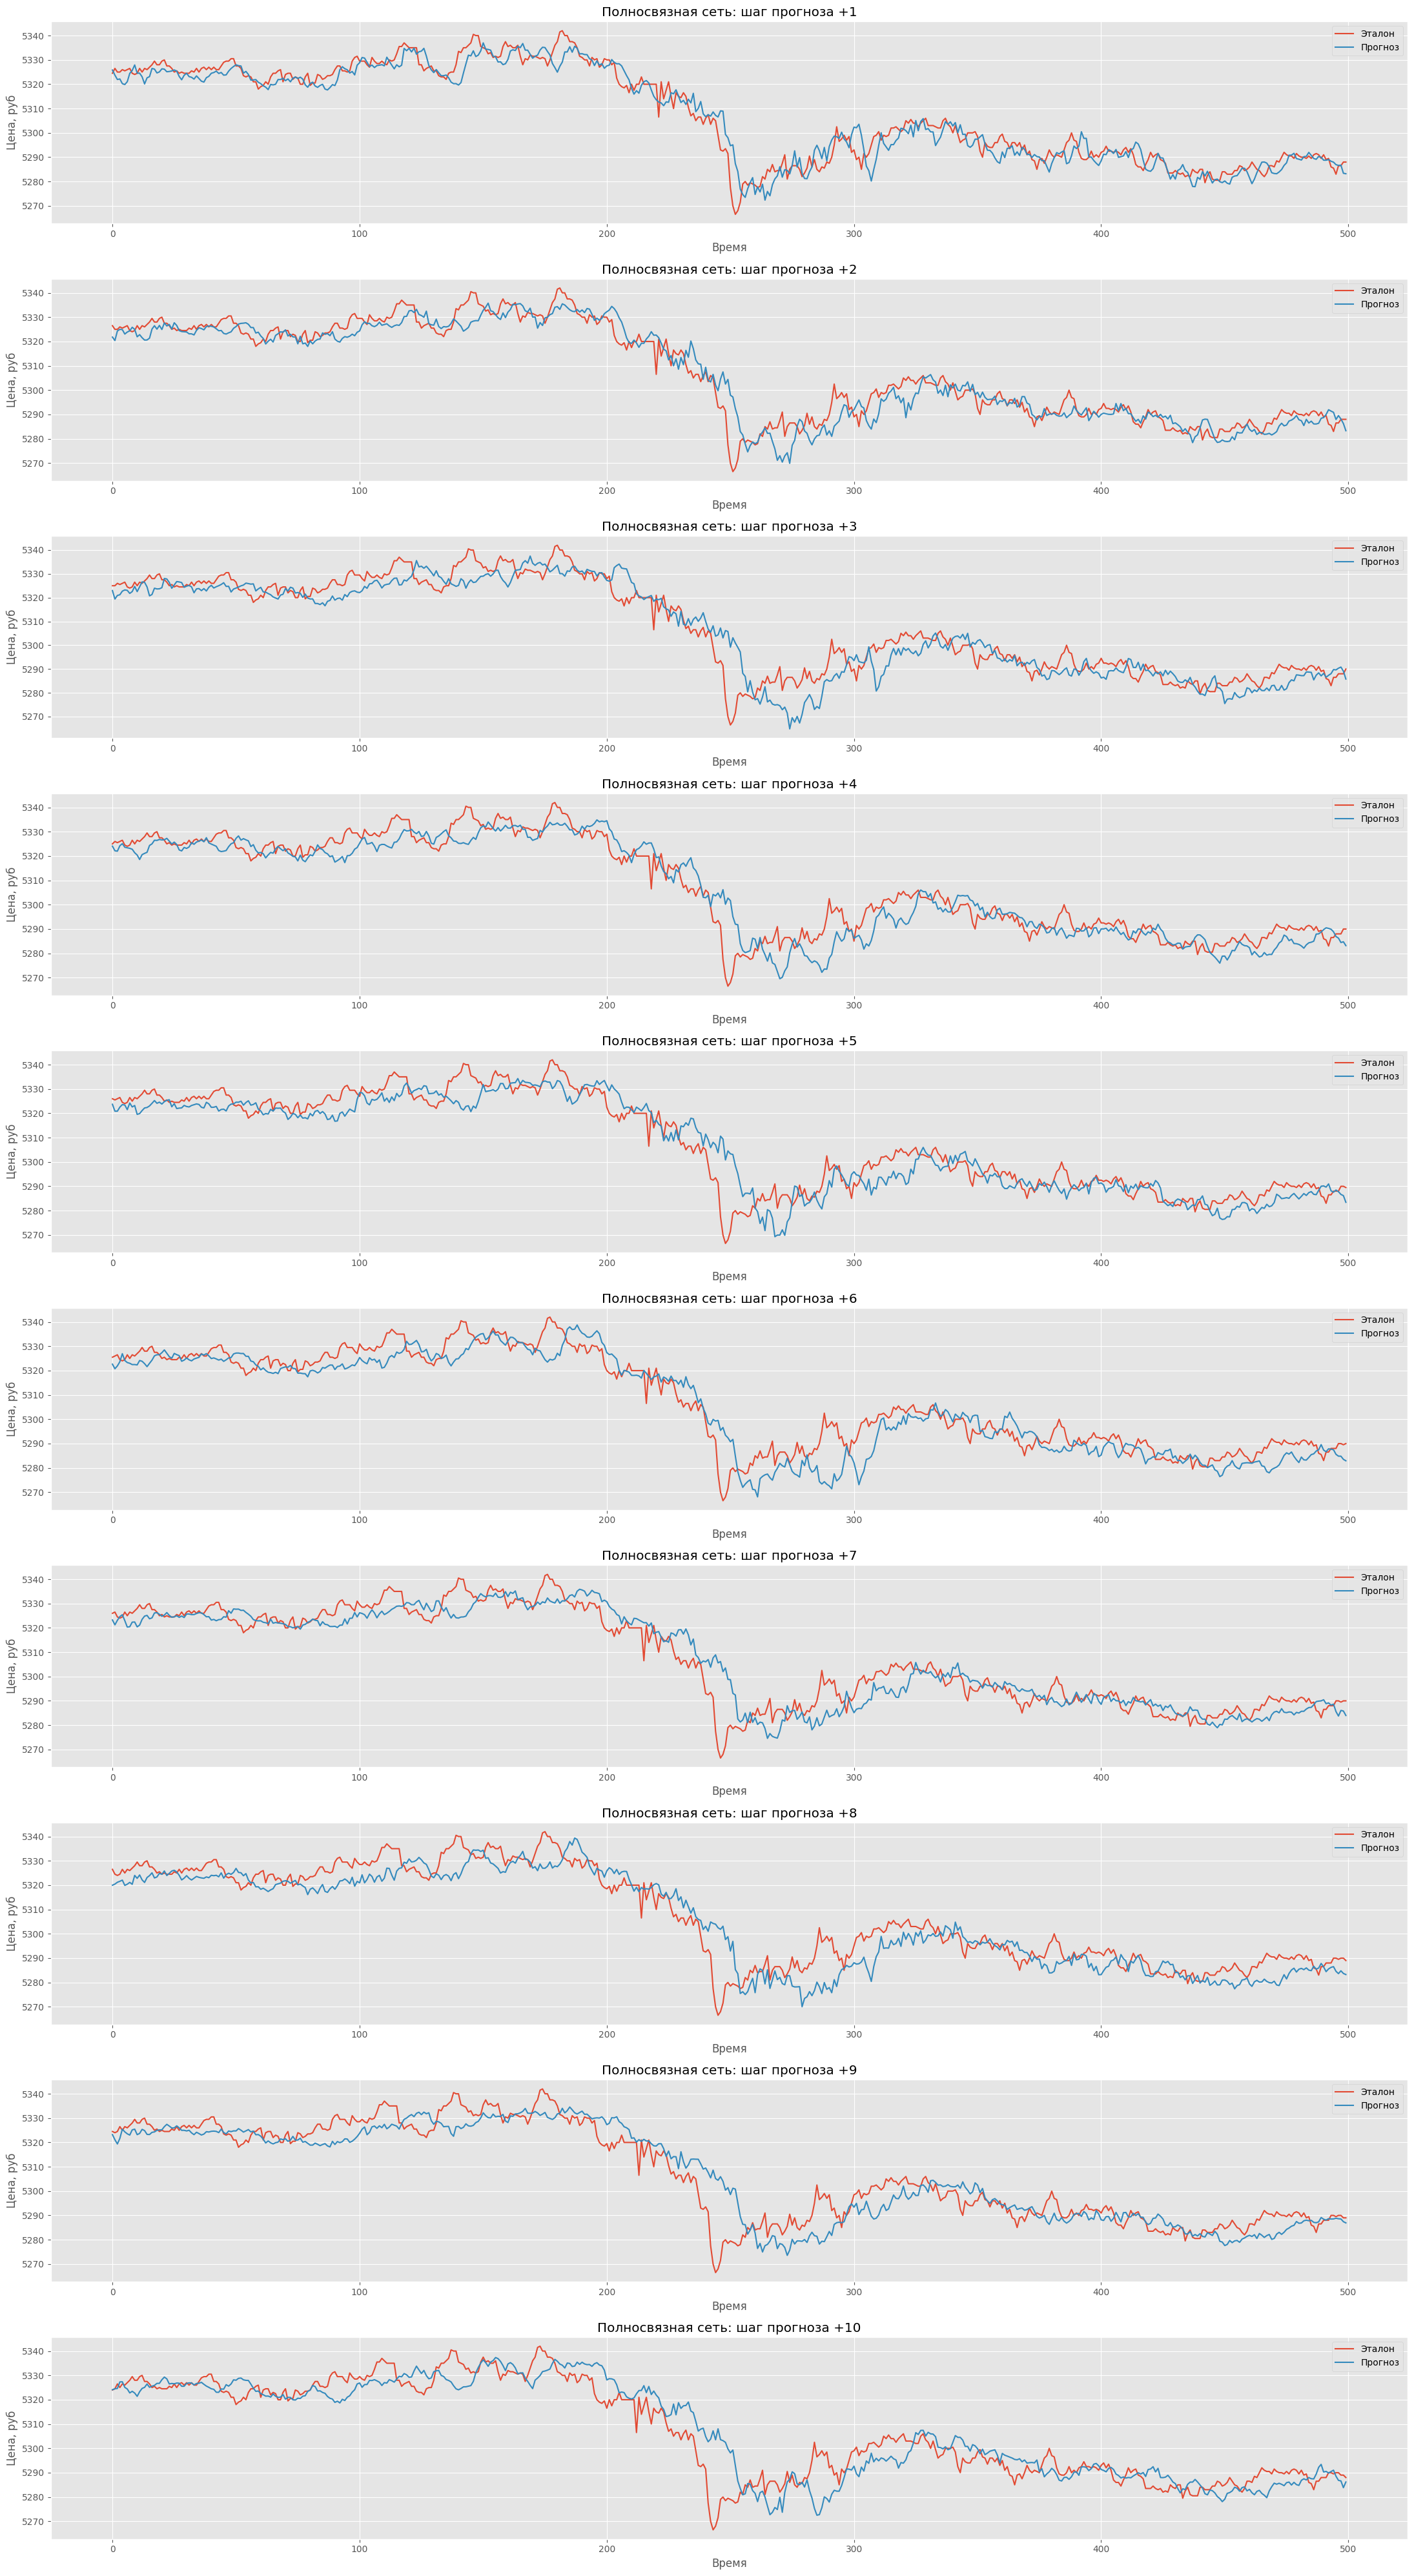

In [20]:
# 10 отдельных графиков (10 рядов на разных осях)
start = 0
length = 500

fig, axes = plt.subplots(PREDICT_LAG, 1, figsize=(22, 4 * PREDICT_LAG))

for step in range(PREDICT_LAG):
    ax = axes[step]
    ax.plot(y_true_m[start:start + length, step], label='Эталон')
    ax.plot(y_pred_m[start:start + length, step], label='Прогноз')
    ax.set_title(f'Полносвязная сеть: шаг прогноза +{step + 1}')
    ax.set_xlabel('Время')
    ax.set_ylabel('Цена, руб')
    ax.legend()

plt.tight_layout()
plt.show()

На ближайших шагах прогноза предсказание полносвязной сети плотно повторяет эталон, что характерно для задач прогнозирования временных рядов с заметной автокорреляцией. По мере увеличения горизонта прогноза (шаги 5–10) предсказание начинает запаздывать и сглаживается, что закономерно: чем дальше прогноз, тем меньше информации о цели содержится во входном окне.

## Часть 3. Свёрточная сеть Conv1D

Для второй архитектуры используются одномерные свёрточные слои. Conv1D эффективен при работе с временными рядами: ядро свёртки обнаруживает локальные паттерны на коротких участках входной последовательности.

### Conv1D, прогноз на 1 шаг вперёд

In [21]:
# Сеть Conv1D с одним выходом
model_conv_1 = Sequential()
model_conv_1.add(Conv1D(64, 5, input_shape=x_test.shape[1:], activation='relu'))
model_conv_1.add(Conv1D(64, 5, activation='relu'))
model_conv_1.add(Flatten())
model_conv_1.add(Dense(100, activation='relu'))
model_conv_1.add(Dense(1, activation='linear'))

model_conv_1.compile(loss='mse', optimizer=Adam(learning_rate=1e-4))
model_conv_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 56, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 52, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3328)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       332,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,929 (1.35 MB)

 Trainable params: 353,929 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Обучение
history_c1 = model_conv_1.fit(train_gen,
                              epochs=8,
                              validation_data=test_gen,
                              verbose=1)

Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0024 - val_loss: 1.7649e-04
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.1789e-05 - val_loss: 1.6361e-04
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.8354e-05 - val_loss: 1.3484e-04
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5584e-04 - val_loss: 1.3591e-04
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4909e-04 - val_loss: 1.2634e-04
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.8046e-05 - val_loss: 1.2526e-04
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9.5570e-05 - val_loss: 1.1800e-04
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.9717e-04 - val_loss: 6.9074e-04


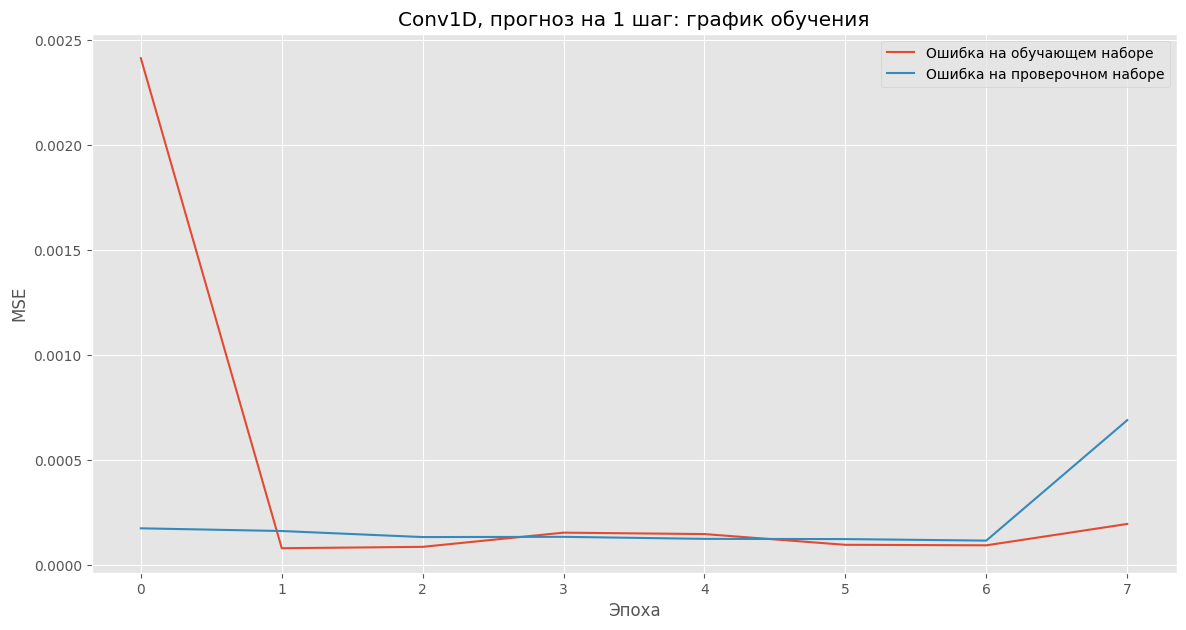

In [23]:
# График обучения
plt.figure(figsize=(14, 7))
plt.plot(history_c1.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history_c1.history['val_loss'], label='Ошибка на проверочном наборе')
plt.title('Conv1D, прогноз на 1 шаг: график обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


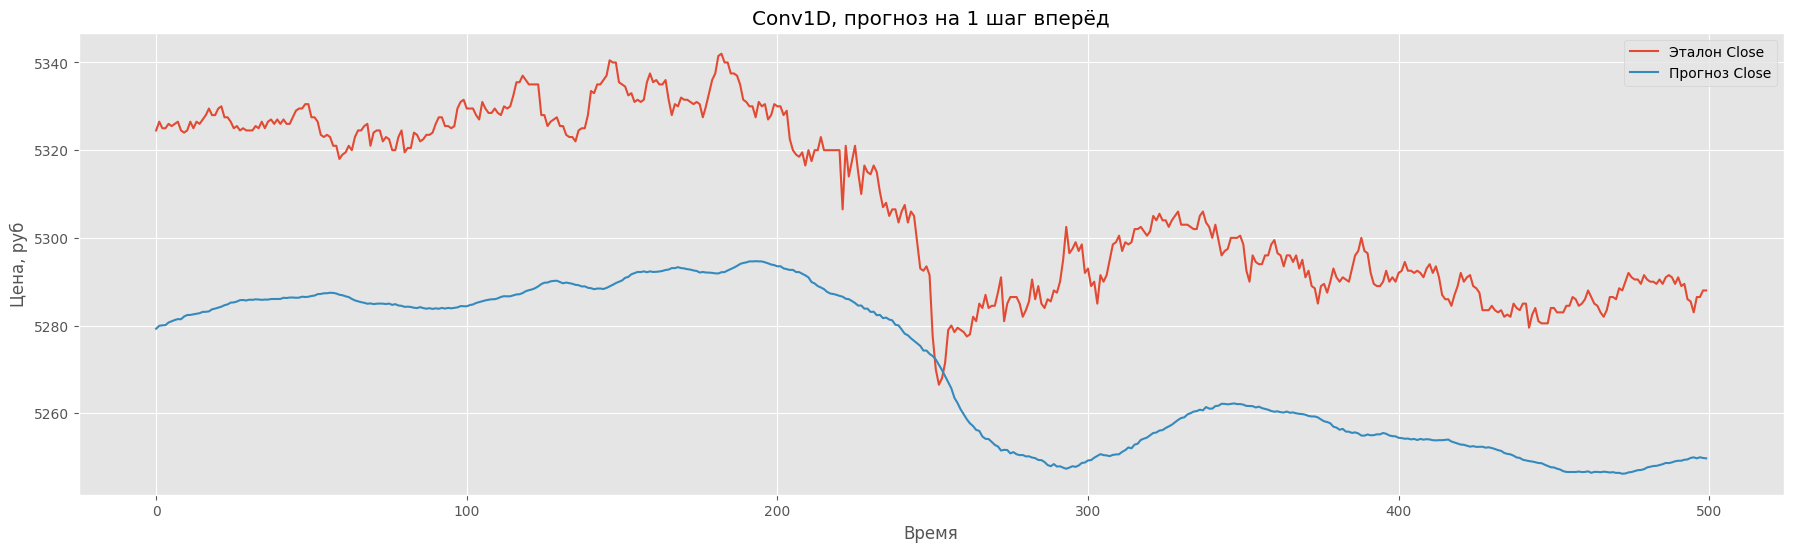

In [24]:
# Сопоставление прогноза и эталона
y_pred_c1 = scaler.inverse_transform(model_conv_1.predict(x_test))
y_true_c1 = scaler.inverse_transform(y_test)

start = 0
length = 500

plt.figure(figsize=(22, 6))
plt.plot(y_true_c1[start:start + length], label='Эталон Close')
plt.plot(y_pred_c1[start:start + length], label='Прогноз Close')
plt.title('Conv1D, прогноз на 1 шаг вперёд')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.show()

### Conv1D, прямой прогноз на 10 шагов вперёд

In [25]:
# Conv1D с 10 выходами
model_conv_10 = Sequential()
model_conv_10.add(Conv1D(64, 5, input_shape=x_train_m.shape[1:], activation='relu'))
model_conv_10.add(Conv1D(64, 5, activation='relu'))
model_conv_10.add(Flatten())
model_conv_10.add(Dense(100, activation='relu'))
model_conv_10.add(Dense(PREDICT_LAG, activation='linear'))

model_conv_10.compile(loss='mse', optimizer=Adam(learning_rate=1e-4))
model_conv_10.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 56, 64)         │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 52, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3328)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       332,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,838 (1.35 MB)

 Trainable params: 354,838 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Обучение
history_c10 = model_conv_10.fit(x_train_m, y_train_m,
                                validation_data=(x_test_m, y_test_m),
                                epochs=8,
                                batch_size=BATCH_SIZE,
                                verbose=1)

Epoch 1/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0114 - val_loss: 2.0263e-04
Epoch 2/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8.2466e-05 - val_loss: 1.6182e-04
Epoch 3/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3096e-05 - val_loss: 1.0348e-04
Epoch 4/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.5081e-05 - val_loss: 7.5968e-05
Epoch 5/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.7971e-05 - val_loss: 6.4812e-05
Epoch 6/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.5380e-05 - val_loss: 6.1796e-05
Epoch 7/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.3505e-05 - val_loss: 5.7049e-05
Epoch 8/8
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.2569e-05 - val_loss: 5.5623e-05


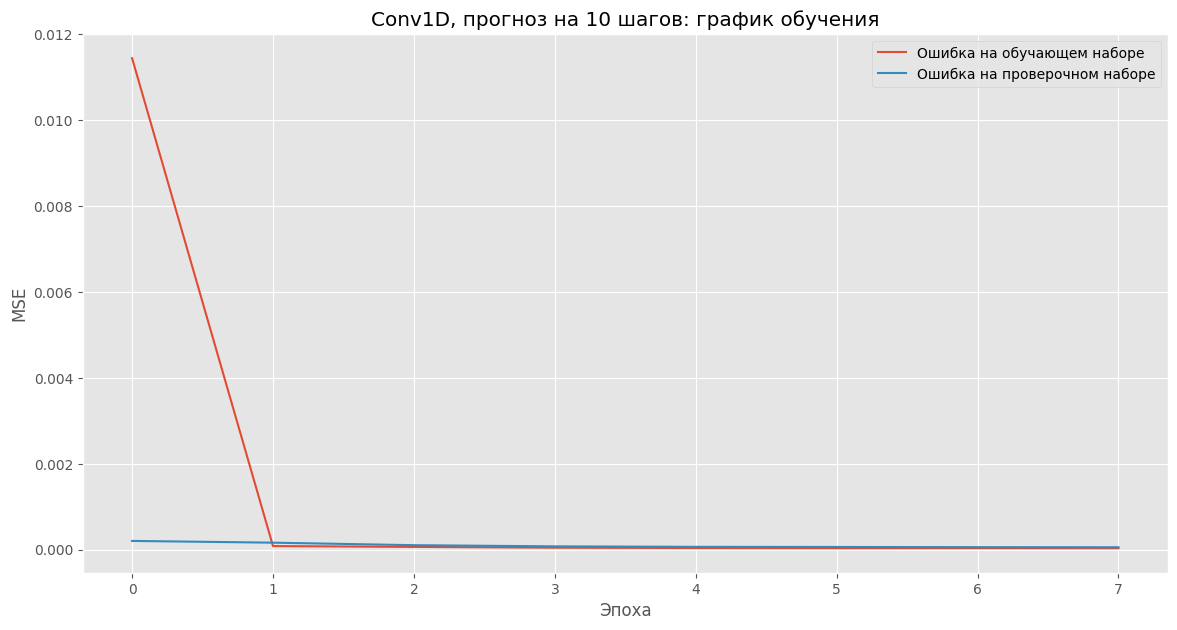

In [27]:
# График обучения
plt.figure(figsize=(14, 7))
plt.plot(history_c10.history['loss'], label='Ошибка на обучающем наборе')
plt.plot(history_c10.history['val_loss'], label='Ошибка на проверочном наборе')
plt.title('Conv1D, прогноз на 10 шагов: график обучения')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.show()

### Графики сравнения предсказания Conv1D с оригинальным сигналом по 10 шагам

155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


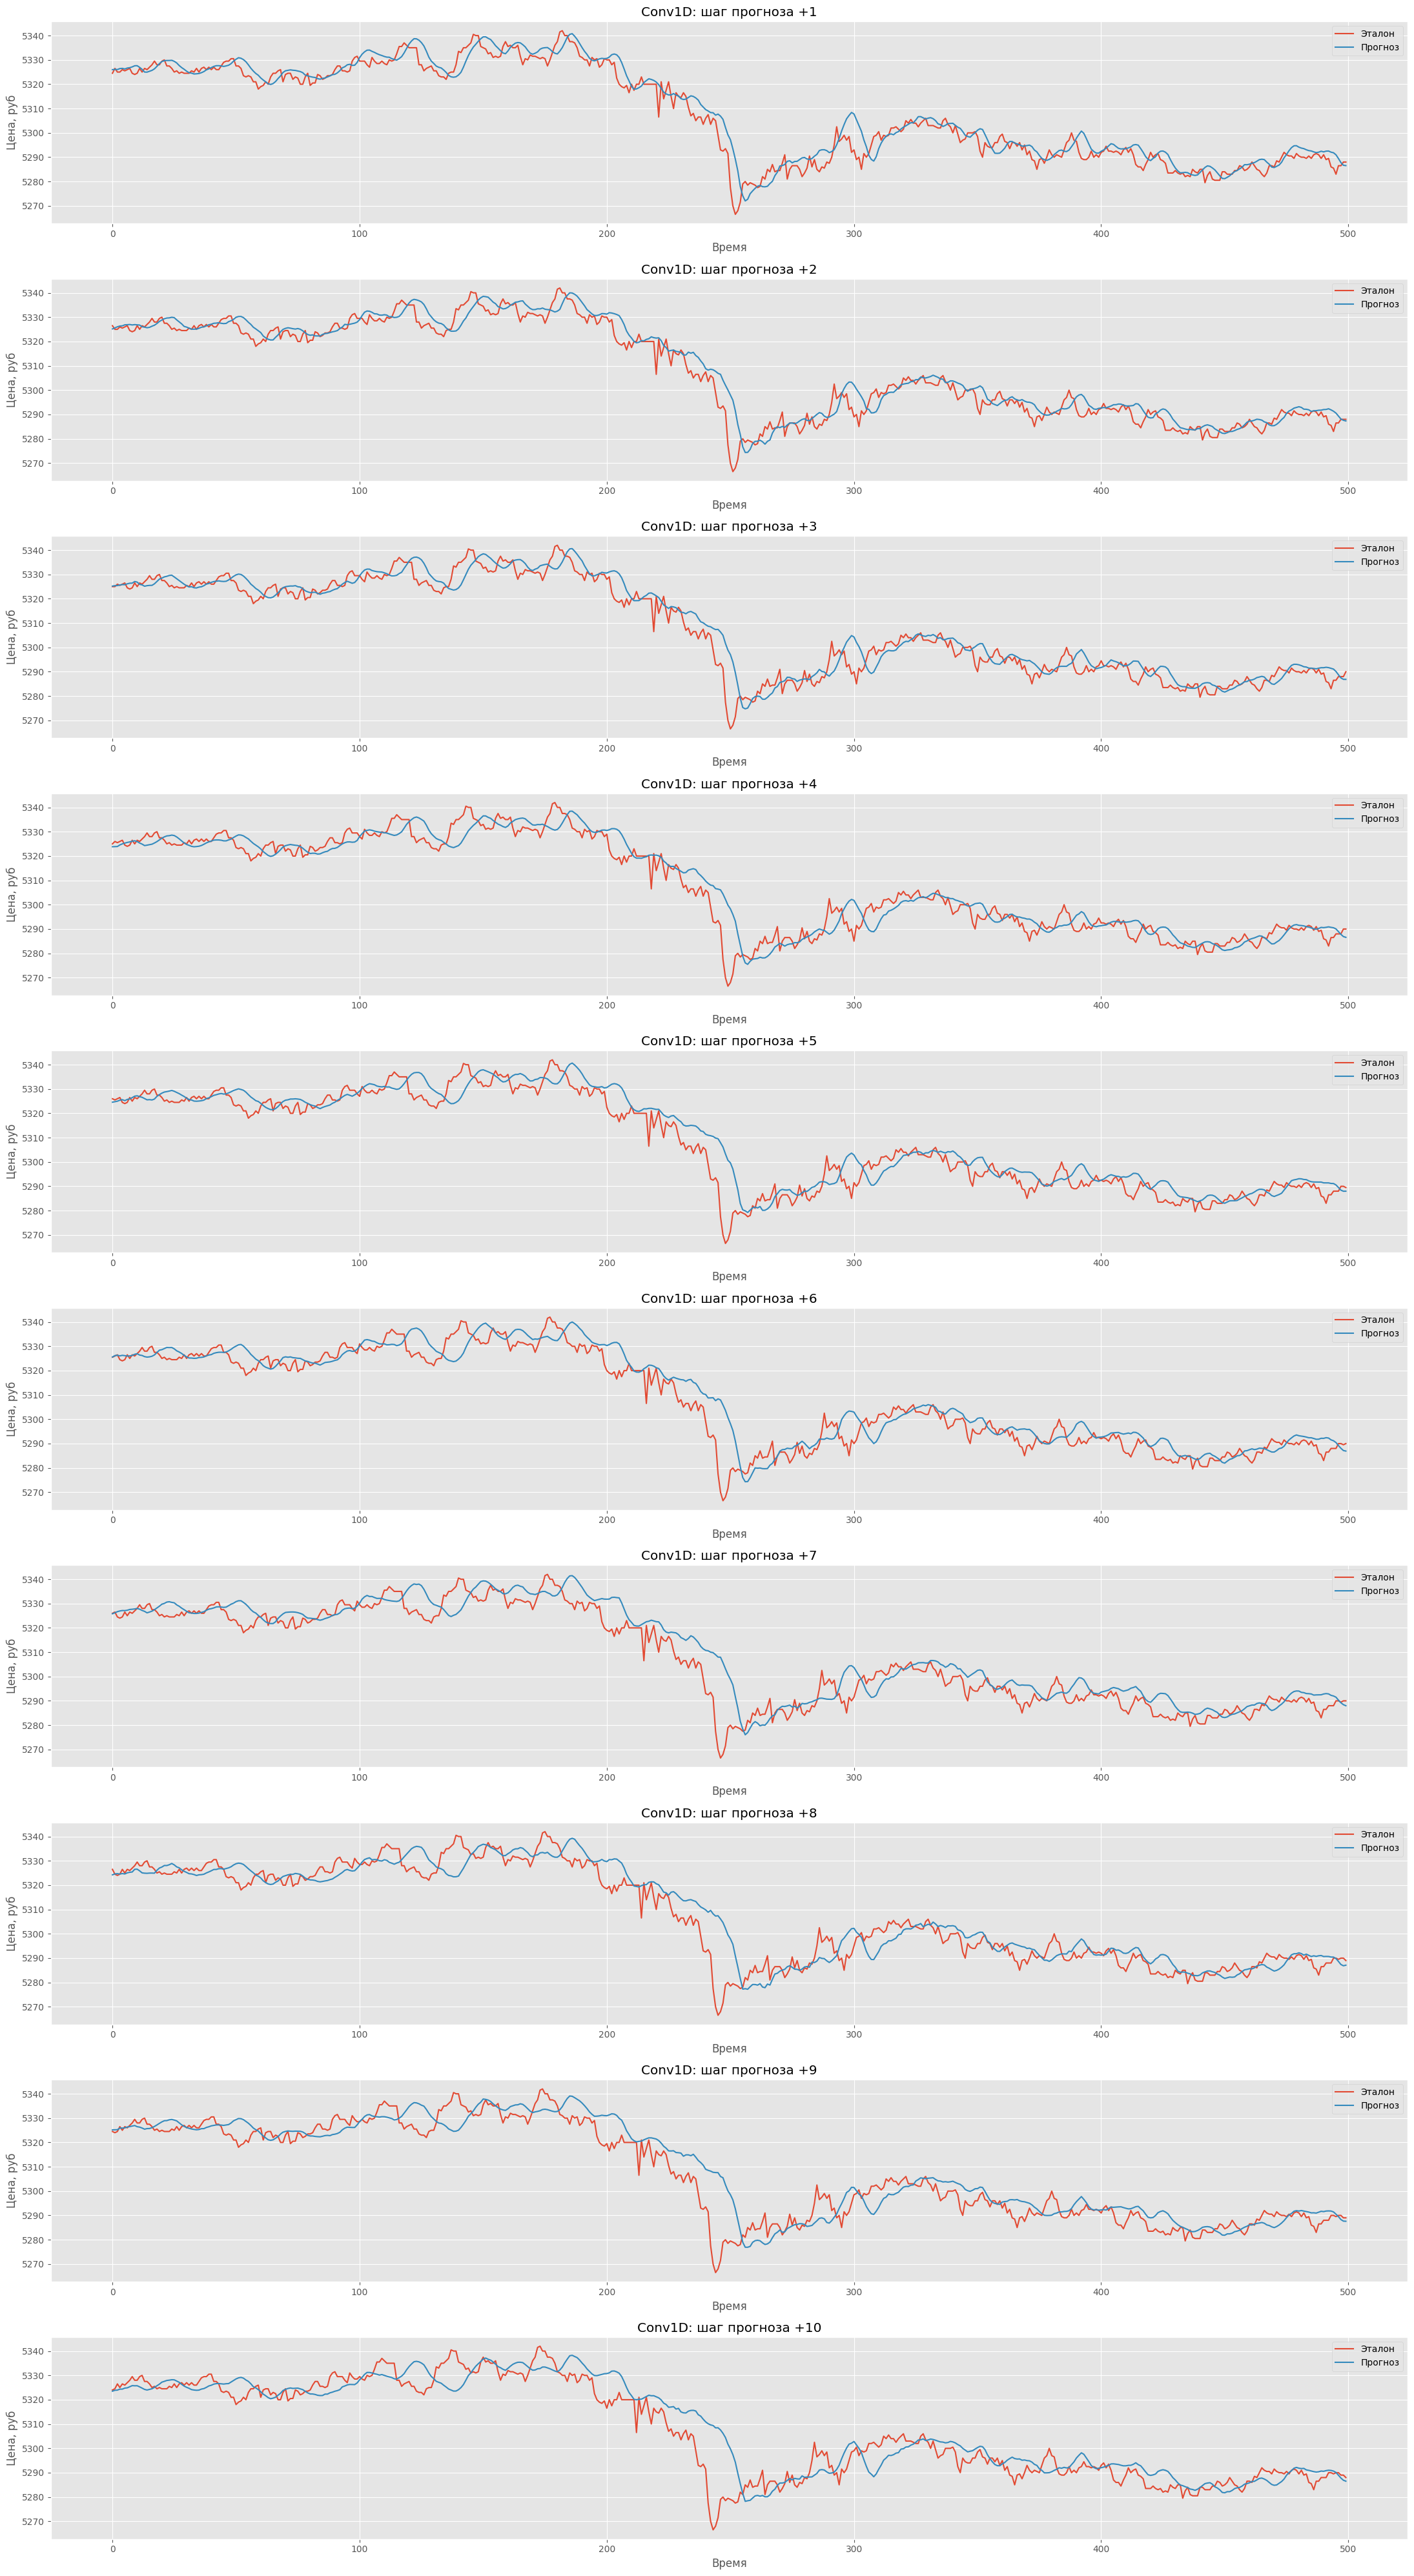

In [28]:
# Прогноз на тестовой выборке и обратная нормализация
y_pred_cm_sc = model_conv_10.predict(x_test_m)
y_pred_cm = scaler.inverse_transform(y_pred_cm_sc.reshape(-1, 1)).reshape(y_pred_cm_sc.shape)
y_true_cm = scaler.inverse_transform(y_test_m.reshape(-1, 1)).reshape(y_test_m.shape)

# 10 отдельных графиков
start = 0
length = 500

fig, axes = plt.subplots(PREDICT_LAG, 1, figsize=(22, 4 * PREDICT_LAG))

for step in range(PREDICT_LAG):
    ax = axes[step]
    ax.plot(y_true_cm[start:start + length, step], label='Эталон')
    ax.plot(y_pred_cm[start:start + length, step], label='Прогноз')
    ax.set_title(f'Conv1D: шаг прогноза +{step + 1}')
    ax.set_xlabel('Время')
    ax.set_ylabel('Цена, руб')
    ax.legend()

plt.tight_layout()
plt.show()